# PHQ-8 Depression Detection — Early Fusion: Mental-RoBERTa + WavLM

**Early fusion** combines the raw backbone features — before any sequence modelling — into a single joint sequence that a new LSTM learns from scratch.

```
text chunk features  (768-dim) + modality flag 0 → (T_text,  769)
audio segment features (768-dim) + modality flag 1 → (T_audio, 769)
                                                  │
                          concat  →  (T_text + T_audio, 769)
                                                  │
                    [trainable LSTM(769, 128)] → (T, 128)
                    attention pooling → 128-dim
                    LayerNorm + MLP(128→64→1)
```

**No pre-trained classifier weights** are loaded — the LSTM and MLP are trained from scratch on the combined sequence.  
**Modality flag**: a single scalar appended to each 768-dim feature vector (0 = text chunk, 1 = audio segment) lets the LSTM distinguish modalities.  
**EDA virtual participants**: their augmented text chunks are paired with the real participant's audio segments (214 training examples).  
**Training augmentation**: chunk subsampling on the text portion + Gaussian noise on all feature dimensions.

## 1. Install Dependencies

In [2]:
!pip install transformers tqdm pandas numpy scikit-learn matplotlib --quiet
print("All packages ready.")

All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Configuration

In [3]:
import os
import random

import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim import Adam

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Imports successful.")

Imports successful.


In [4]:
# --- Reproducibility ---
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Paths ---
BASE_DIR      = Path("..")
DATASET_DIR   = BASE_DIR / "dataset"
PROCESSED_DIR = BASE_DIR / "processed"

TRAIN_CSV = DATASET_DIR / "train_split_Depression_AVEC2017.csv"
DEV_CSV   = DATASET_DIR / "dev_split_Depression_AVEC2017.csv"
TEST_CSV  = DATASET_DIR / "full_test_split.csv"

TEXT_FEATURE_CACHE     = PROCESSED_DIR / "mental_roberta_features_cls.npz"
EDA_TEXT_FEATURE_CACHE = PROCESSED_DIR / "mental_roberta_features_eda_cls.npz"
AUDIO_FEATURE_CACHE    = PROCESSED_DIR / "wavlm_features_cls.npz"

SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "early_fusion_mentalroberta_wavlm"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Modality flags appended to each 768-dim feature vector
TEXT_FLAG  = 0.0
AUDIO_FLAG = 1.0
FEAT_DIM   = 769   # 768 backbone features + 1 modality flag

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seed: {SEED}  |  Device: {DEVICE}")
print(f"Combined feature dim: {FEAT_DIM}  (768 backbone + 1 modality flag)")

Seed: 42  |  Device: cuda
Combined feature dim: 769  (768 backbone + 1 modality flag)


## 3. Load Label Files

In [5]:
train_df = pd.read_csv(TRAIN_CSV)[["Participant_ID", "PHQ8_Binary"]]
dev_df   = pd.read_csv(DEV_CSV)[["Participant_ID", "PHQ8_Binary"]]
test_df  = pd.read_csv(TEST_CSV)[["Participant_ID", "PHQ_Binary"]].rename(
    columns={"PHQ_Binary": "PHQ8_Binary"}
)

train_labels = dict(zip(train_df.Participant_ID, train_df.PHQ8_Binary))
dev_labels   = dict(zip(dev_df.Participant_ID,   dev_df.PHQ8_Binary))
test_labels  = dict(zip(test_df.Participant_ID,  test_df.PHQ8_Binary))
pid_to_split = (
    {pid: "train" for pid in train_labels}
    | {pid: "dev"   for pid in dev_labels}
    | {pid: "test"  for pid in test_labels}
)

for name, labels in [("Train", train_labels), ("Dev", dev_labels), ("Test", test_labels)]:
    dep = sum(labels.values())
    print(f"{name:5s}: {len(labels):3d} participants  depressed: {dep}  control: {len(labels)-dep}")

Train: 107 participants  depressed: 30  control: 77
Dev  :  35 participants  depressed: 12  control: 23
Test :  47 participants  depressed: 14  control: 33


## 4. Load Pre-extracted Features

In [6]:
def load_participant_features(cache_path: Path, label: str, eda_cache_path: Path = None):
    assert cache_path.exists(), f"Cache not found: {cache_path}"
    print(f"Loading {label} from {cache_path.name} ...")
    cache = np.load(cache_path, allow_pickle=False)
    in_memory = {
        "train": defaultdict(lambda: {"feats": [], "label": None}),
        "dev":   defaultdict(lambda: {"feats": [], "label": None}),
        "test":  defaultdict(lambda: {"feats": [], "label": None}),
    }
    for feat, lbl, pid, split_b in zip(
        cache["feats"], cache["binary_labels"], cache["pids"], cache["splits"]
    ):
        s = split_b.decode(); pid = int(pid)
        in_memory[s][pid]["feats"].append(feat)
        in_memory[s][pid]["label"] = int(lbl)

    if eda_cache_path is not None and eda_cache_path.exists():
        print(f"  + EDA features from {eda_cache_path.name}")
        eda = np.load(eda_cache_path, allow_pickle=False)
        eda_virtual = defaultdict(lambda: {"feats": [], "label": None})
        for feat, lbl, pid, aug_i in zip(
            eda["feats"], eda["binary_labels"], eda["pids"], eda["aug_indices"]
        ):
            vpid = int(pid) * 1000 + int(aug_i)
            eda_virtual[vpid]["feats"].append(feat)
            eda_virtual[vpid]["label"] = int(lbl)
        for vpid, data in eda_virtual.items():
            in_memory["train"][vpid] = data
        n_dep = sum(d["label"] for d in eda_virtual.values())
        print(f"  Added {len(eda_virtual)} EDA virtual participants "
              f"(dep: {n_dep}  ctrl: {len(eda_virtual)-n_dep})")

    splits_list = {s: list(in_memory[s].items()) for s in ("train", "dev", "test")}
    for s, name in [("train", "train"), ("dev", "val"), ("test", "test")]:
        n_p = len(splits_list[s])
        n_d = sum(d["label"] for _, d in splits_list[s])
        print(f"  {name:5s}: {n_p} participants  dep: {n_d}  ctrl: {n_p-n_d}")
    return splits_list


text_splits  = load_participant_features(TEXT_FEATURE_CACHE, "text", EDA_TEXT_FEATURE_CACHE)
print()
audio_splits = load_participant_features(AUDIO_FEATURE_CACHE, "audio")

Loading text from mental_roberta_features_cls.npz ...
  + EDA features from mental_roberta_features_eda_cls.npz
  Added 107 EDA virtual participants (dep: 30  ctrl: 77)
  train: 214 participants  dep: 60  ctrl: 154
  val  : 35 participants  dep: 12  ctrl: 23
  test : 47 participants  dep: 14  ctrl: 33

Loading audio from wavlm_features_cls.npz ...
  train: 107 participants  dep: 30  ctrl: 77
  val  : 35 participants  dep: 12  ctrl: 23
  test : 47 participants  dep: 14  ctrl: 33


## 5. Build Combined Participant Dataset

For each participant:
1. Append modality flag to each feature: text chunks get `0.0`, audio segments get `1.0`
2. Concatenate into one sequence: `[text_chunks | audio_segments]` → shape `(T_text + T_audio, 769)`
3. Store `n_text` (number of text chunks) to enable text-only chunk subsampling during training

For EDA virtual participants (train only), their augmented text chunks are combined with the
real participant's audio segments (`real_pid = virtual_pid // 1000`).

In [7]:
def add_modality_flag(feats: np.ndarray, flag: float) -> np.ndarray:
    """Append a scalar modality flag to every row: (T, 768) → (T, 769)."""
    flags = np.full((len(feats), 1), fill_value=flag, dtype=np.float32)
    return np.hstack([feats, flags])


def build_combined(text_feats: list, audio_feats: list):
    """Returns combined array (T_text+T_audio, 769) and n_text."""
    text_arr  = add_modality_flag(np.array(text_feats,  dtype=np.float32), TEXT_FLAG)
    audio_arr = add_modality_flag(np.array(audio_feats, dtype=np.float32), AUDIO_FLAG)
    return np.vstack([text_arr, audio_arr]), len(text_feats)


def build_split_dataset(text_sp: list, audio_sp: list,
                         is_train: bool = False) -> list:
    """
    Build the combined dataset for one split.
    For train:
      - Real participants: direct text + audio combination.
      - EDA virtual participants (pid > 10000): their text chunks
        combined with the real participant's audio (real_pid = pid // 1000).
    For dev/test: strict match only (real participants).
    """
    real_audio = {pid: data for pid, data in audio_sp}
    dataset = []

    for pid, text_data in text_sp:
        if pid in real_audio:
            # Real participant
            audio_data = real_audio[pid]
        elif is_train and pid > 10_000:
            # EDA virtual: use the real participant's audio
            real_pid = pid // 1000
            if real_pid not in real_audio:
                continue
            audio_data = real_audio[real_pid]
        else:
            continue   # no matching audio → skip

        combined, n_text = build_combined(text_data["feats"], audio_data["feats"])
        dataset.append((pid, {
            "combined": combined,
            "n_text":   n_text,
            "label":    text_data["label"],
        }))
    return dataset


train_data = build_split_dataset(text_splits["train"], audio_splits["train"], is_train=True)
dev_data   = build_split_dataset(text_splits["dev"],   audio_splits["dev"])
test_data  = build_split_dataset(text_splits["test"],  audio_splits["test"])

print(f"{'Split':5s}  {'Participants':>12}  {'Avg seq len':>11}  {'Depressed':>9}  {'Control':>7}")
print("-" * 52)
for name, data in [("train", train_data), ("dev", dev_data), ("test", test_data)]:
    avg_len = np.mean([d["combined"].shape[0] for _, d in data])
    n_dep   = sum(d["label"] for _, d in data)
    print(f"{name:5s}  {len(data):12d}  {avg_len:11.1f}  {n_dep:9d}  {len(data)-n_dep:7d}")

Split  Participants  Avg seq len  Depressed  Control
----------------------------------------------------
train           214        115.8         60      154
dev              35        133.6         12       23
test             47        136.7         14       33


## 6. Model Architecture — Early Fusion LSTM

```
Input  : (T_text + T_audio, 769)   — combined modality-tagged sequence
         ↓ Dropout
         ↓ LSTM(769, 128)
         ↓ attention pooling → 128-dim
         ↓ LayerNorm(128)
         ↓ Linear(128, 64) + ReLU + Dropout
         ↓ Linear(64, 1)
Output : scalar logit
```

In [8]:
LSTM_HIDDEN    = 128
LSTM_LAYERS    = 1
LSTM_BIDIR     = False
MLP_HIDDEN     = 64
DROPOUT        = 0.5

LSTM_OUT_DIM   = LSTM_HIDDEN * (2 if LSTM_BIDIR else 1)


class EarlyFusionLSTMClassifier(nn.Module):
    """
    Trained from scratch on the combined text+audio feature sequence.

    Input  : (T, 769)  — concatenated text chunks and audio segments,
                         each annotated with a 0/1 modality flag.
    Output : scalar logit
    """
    def __init__(self,
                 input_dim:     int   = FEAT_DIM,
                 lstm_hidden:   int   = LSTM_HIDDEN,
                 lstm_layers:   int   = LSTM_LAYERS,
                 bidirectional: bool  = LSTM_BIDIR,
                 hidden_dim:    int   = MLP_HIDDEN,
                 dropout:       float = DROPOUT):
        super().__init__()
        self.lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.attention     = nn.Linear(self.lstm_out_dim, 1)
        self.norm          = nn.LayerNorm(self.lstm_out_dim)
        self.input_dropout = nn.Dropout(dropout)
        self.classifier    = nn.Sequential(
            nn.Linear(self.lstm_out_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (T, 769)
        enc, _ = self.lstm(self.input_dropout(x).unsqueeze(0))
        enc    = enc.squeeze(0)                                    # (T, lstm_out_dim)
        attn_w = torch.softmax(self.attention(enc), dim=0)
        pooled = self.norm((attn_w * enc).sum(dim=0))
        return self.classifier(pooled).squeeze()


model = EarlyFusionLSTMClassifier().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"EarlyFusionLSTMClassifier trainable parameters: {n_params:,}")

with torch.no_grad():
    dummy = torch.zeros(20, FEAT_DIM, device=DEVICE)   # 20-step sequence
    print(f"Output shape (20 steps): {model(dummy).shape}  (expected: torch.Size([]))")

EarlyFusionLSTMClassifier trainable parameters: 468,994
Output shape (20 steps): torch.Size([])  (expected: torch.Size([]))


## 7. Training Configuration

In [9]:
PARTICIPANT_BATCH_SIZE  = 16
NUM_EPOCHS              = 500
LEARNING_RATE           = 1e-4
WEIGHT_DECAY            = 1e-4
EARLY_STOPPING_PATIENCE = 50
CHECKPOINT_FREQ         = 50
GRAD_CLIP_NORM          = 1.0
AUGMENT_NOISE_STD       = 0.03    # Gaussian noise on the 768-dim backbone features
AUGMENT_CHUNK_KEEP      = 0.75    # min fraction of text chunks to keep per training pass

n_dep_train  = sum(d["label"] for _, d in train_data)
n_ctrl_train = len(train_data) - n_dep_train
pos_weight   = torch.tensor(n_ctrl_train / n_dep_train, dtype=torch.float32, device=DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(f"Training participants : {len(train_data)}  (dep: {n_dep_train}  ctrl: {n_ctrl_train})")
print(f"pos_weight            : {pos_weight.item():.4f}")
print(f"Batch size            : {PARTICIPANT_BATCH_SIZE}")
print(f"Epochs                : {NUM_EPOCHS}  (patience {EARLY_STOPPING_PATIENCE})")
print(f"Augmentation          : noise_std={AUGMENT_NOISE_STD}  "
      f"chunk_keep_min={AUGMENT_CHUNK_KEEP:.0%}")

Training participants : 214  (dep: 60  ctrl: 154)
pos_weight            : 2.5667
Batch size            : 16
Epochs                : 500  (patience 50)
Augmentation          : noise_std=0.03  chunk_keep_min=75%


## 8. Training Loop

**Augmentation** (training only):
- **Text chunk subsampling**: randomly keep `AUGMENT_CHUNK_KEEP`–100% of the text chunks (preserving order). Audio segments are always kept in full.
- **Gaussian noise**: added to the backbone feature dimensions (`[:768]`); the modality flag dimension is left unchanged.

In [10]:
def augment(combined: torch.Tensor, n_text: int) -> torch.Tensor:
    """
    combined : (T_text + T_audio, 769)
    n_text   : number of text chunks at the start of the sequence

    1. Randomly subsample text-chunk rows (preserving order).
    2. Add Gaussian noise to the first 768 dimensions only.
    """
    if n_text > 1:
        keep_frac = AUGMENT_CHUNK_KEEP + (1.0 - AUGMENT_CHUNK_KEEP) * torch.rand(1).item()
        n_keep    = max(1, int(n_text * keep_frac))
        text_idx  = torch.randperm(n_text)[:n_keep].sort().values
        audio_idx = torch.arange(n_text, combined.size(0))
        combined  = combined[torch.cat([text_idx, audio_idx])]

    # Noise only on backbone feature dims (not the modality flag)
    noise = torch.zeros_like(combined)
    noise[:, :768] = torch.randn(combined.size(0), 768, device=combined.device) * AUGMENT_NOISE_STD
    return combined + noise


def train_epoch():
    model.train()
    idx     = torch.randperm(len(train_data)).tolist()
    batches = [idx[i : i + PARTICIPANT_BATCH_SIZE]
               for i in range(0, len(idx), PARTICIPANT_BATCH_SIZE)]
    total_loss, correct, n = 0.0, 0, len(train_data)

    for batch in batches:
        optimizer.zero_grad()
        for i in batch:
            _, data = train_data[i]
            combined = torch.tensor(data["combined"], dtype=torch.float32, device=DEVICE)
            combined = augment(combined, data["n_text"])
            label    = torch.tensor(float(data["label"]), dtype=torch.float32, device=DEVICE)

            logit = model(combined)
            loss  = criterion(logit, label) / len(batch)
            loss.backward()
            total_loss += loss.item() * len(batch)
            correct    += int((1 if torch.sigmoid(logit).item() >= 0.5 else 0) == data["label"])

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
    return total_loss / n, correct / n


def evaluate(data: list, threshold: float = 0.5):
    model.eval()
    total_loss, records = 0.0, []
    with torch.no_grad():
        for pid, d in data:
            combined = torch.tensor(d["combined"], dtype=torch.float32, device=DEVICE)
            label    = torch.tensor(float(d["label"]), dtype=torch.float32, device=DEVICE)
            logit    = model(combined)
            total_loss += criterion(logit, label).item()
            prob = torch.sigmoid(logit).item()
            records.append((pid, 1 if prob >= threshold else 0, prob, d["label"]))
    df       = pd.DataFrame(records, columns=["pid", "pred", "prob", "label"])
    acc      = accuracy_score(df["label"], df["pred"])
    macro_f1 = f1_score(df["label"], df["pred"], average="macro", zero_division=0)
    return total_loss / len(data), acc, macro_f1, df


# ── Training ─────────────────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   [], "val_f1": []}
best_val_f1       = -1.0
epochs_no_improve = 0
best_ckpt         = None

print(f"{'Epoch':>6}  {'TrainLoss':>9}  {'TrainAcc':>8}  "
      f"{'ValLoss':>7}  {'ValAcc':>6}  {'ValF1':>7}")
print("-" * 58)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc         = train_epoch()
    val_loss, val_acc, val_f1, _  = evaluate(dev_data)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if epoch % CHECKPOINT_FREQ == 0:
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                    "val_f1": val_f1},
                   SAVE_DIR / f"epoch{epoch}_early_fusion.pth")

    if val_f1 > best_val_f1:
        best_val_f1       = val_f1
        epochs_no_improve = 0
        best_ckpt = {"epoch": epoch, "val_loss": val_loss,
                     "val_acc": val_acc, "val_f1": val_f1,
                     "state": {k: v.cpu().clone()
                               for k, v in model.state_dict().items()}}
        torch.save(best_ckpt["state"], SAVE_DIR / "early_fusion_best.pth")
        print(f"{epoch:6d}  {train_loss:9.4f}  {train_acc:8.4f}  "
              f"{val_loss:7.4f}  {val_acc:6.4f}  {val_f1:7.4f}  *** best")
    else:
        epochs_no_improve += 1
        if epoch % 10 == 0:
            print(f"{epoch:6d}  {train_loss:9.4f}  {train_acc:8.4f}  "
                  f"{val_loss:7.4f}  {val_acc:6.4f}  {val_f1:7.4f}")

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest: epoch={best_ckpt['epoch']}  "
      f"val_loss={best_ckpt['val_loss']:.4f}  "
      f"val_f1={best_ckpt['val_f1']:.4f}")

# Restore best weights
model.load_state_dict(best_ckpt["state"])
model.to(DEVICE)

# Tune threshold on validation set
_, _, _, val_df = evaluate(dev_data)
best_thresh, best_f1 = 0.5, -1.0
for t in np.arange(0.10, 0.91, 0.05):
    f1 = f1_score(val_df["label"], (val_df["prob"] >= t).astype(int),
                  average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1, best_thresh = f1, float(t)
print(f"Best threshold: {best_thresh:.2f}  (val macro-F1 = {best_f1:.4f})")

 Epoch  TrainLoss  TrainAcc  ValLoss  ValAcc    ValF1
----------------------------------------------------------
     1     1.0466    0.6075   1.1068  0.6571   0.3966  *** best
     3     1.0289    0.5514   1.0671  0.6286   0.4950  *** best
     9     0.9789    0.6262   1.0570  0.7143   0.6261  *** best
    10     0.9781    0.5561   1.0550  0.6857   0.6259
    17     0.9704    0.6308   1.0417  0.6857   0.6578  *** best
    19     0.9605    0.6449   1.0354  0.6857   0.6762  *** best
    20     0.9486    0.6916   1.0359  0.6857   0.6578
    30     0.8737    0.6449   0.9771  0.5143   0.5143
    40     0.7112    0.7477   1.1007  0.6286   0.6081
    50     0.6071    0.8178   1.3322  0.5714   0.5478
    60     0.6990    0.7150   1.5822  0.6857   0.6027

Early stopping at epoch 69.

Best: epoch=19  val_loss=1.0354  val_f1=0.6762
Best threshold: 0.50  (val macro-F1 = 0.6762)


## 9. Training Curves

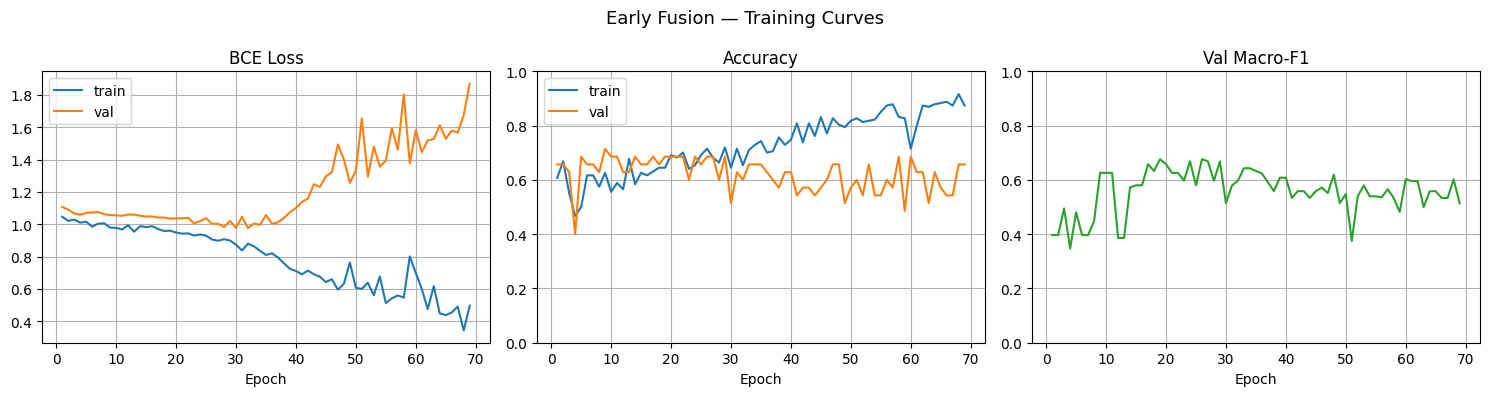

In [11]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_ran, history["train_loss"], label="train", color="tab:blue")
axes[0].plot(epochs_ran, history["val_loss"],   label="val",   color="tab:orange")
axes[0].set_title("BCE Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, history["train_acc"], label="train", color="tab:blue")
axes[1].plot(epochs_ran, history["val_acc"],   label="val",   color="tab:orange")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True)

axes[2].plot(epochs_ran, history["val_f1"], color="tab:green")
axes[2].set_title("Val Macro-F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)
axes[2].grid(True)

plt.suptitle("Early Fusion — Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Test Set Evaluation

In [12]:
_, _, _, test_df = evaluate(test_data, threshold=best_thresh)

y_true = test_df["label"].values.astype(int)
y_pred = test_df["pred"].values.astype(int)

print(f"Best checkpoint : epoch {best_ckpt['epoch']}  "
      f"val_loss={best_ckpt['val_loss']:.4f}  val_f1={best_ckpt['val_f1']:.4f}")
print(f"Decision threshold : {best_thresh:.2f}  (tuned on validation macro-F1)")
print(f"Participants : {len(test_df)}\n")
print(classification_report(y_true, y_pred,
                             target_names=["Control", "Depressed"], zero_division=0))

Best checkpoint : epoch 19  val_loss=1.0354  val_f1=0.6762
Decision threshold : 0.50  (tuned on validation macro-F1)
Participants : 47

              precision    recall  f1-score   support

     Control       0.74      0.79      0.76        33
   Depressed       0.42      0.36      0.38        14

    accuracy                           0.66        47
   macro avg       0.58      0.57      0.57        47
weighted avg       0.65      0.66      0.65        47



## 11. Confusion Matrix

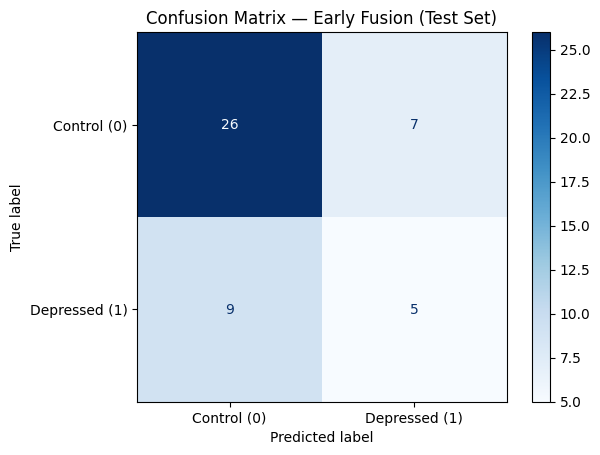

In [13]:
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Control (0)", "Depressed (1)"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Early Fusion (Test Set)")
plt.show()